# 📊 İstatistik ve Veri Bilimi Temelleri
### (Fundamentals of Statistics & Data Science)

---

Bu notebook, veri bilimi ve makine öğrenmesinin temelini oluşturan **İstatistiki Kavramlar**, **Örnekleme Teknikleri**, **Veri Tipleri**, **Dağılım ve Yayılım Ölçüleri (5 Sayı Özeti & IQR)**, **Çarpıklık (Skewness)**, **Kovaryans & Korelasyon** ve **Olasılık Dağılım Fonksiyonları (PMF, PDF, CDF)** konularını hem teorik (matematiksel formüller) hem de pratik (Python, NumPy, Pandas, SciPy, Matplotlib, Seaborn) olarak detaylı bir şekilde ele almaktadır.

### 📑 İçindekiler:
1. **Örnekleme (Sampling) Teknikleri:** Olasılıklı (Probability) ve Olasılıksız (Non-Probability) Yöntemler
2. **İstatistiğe Giriş ve Veri Tipleri:** Betimleyici (Descriptive) vs. Çıkarımsal (Inferential) İstatistik, Sayısal (Quantitative) & Kategorik (Qualitative) Veri Ağacı
3. **Dağılım Ölçüleri ve 5 Sayı Özeti:** Range, Varyans, Standart Sapma, $Q_1, Q_3$, IQR ve Aykırı Değer (Outlier) Tespiti
4. **Çarpıklık (Skewness) ve İlişki Ölçütleri:** Sağa/Sola Çarpık Dağılımlar, Kovaryans (`.cov()`) ve Korelasyon (`.corr()`)
5. **Olasılık Dağılım Fonksiyonları:** PMF, PDF, CDF Kavramları, Ev Fiyat Tahmini Değişken Sınıflandırması, Binom ve Normal Dağılım Simülasyonları
6. **Temel Dağılım Türleri Kataloğu:** Bernoulli, Binomial, Normal, Log-Normal, Pareto, Uniform Dağılımları
7. **Özet ve Hızlı Başvuru Kartı**

---

## 🎯 Bölüm 1: Örnekleme (Sampling) Teknikleri

**Popülasyon (Evren / Population):** İlgilendiğimiz tüm bireylerin, nesnelerin veya olayların oluşturduğu ana kümedir ($N$).
**Örneklem (Sample):** Popülasyonu temsil etmek üzere seçilen daha küçük alt kümedir ($n$).

```
                                  Ö R N E K L E M E   T E K N İ K L E R İ
                                             |
                +----------------------------+----------------------------+
                |                                                         |
     OLASILIKLI ÖRNEKLEME                                      OLASILIKSIZ ÖRNEKLEME
    (Probability Sampling)                                   (Non-Probability Sampling)
                |\                                                         |
   +------------+------------+-----------+            +------------+------------+-----------+
   |            |            |           |            |            |            |           |
Basit        Sistematik   Tabakalı    Kümeleme     Kolayda      Yargısal     Kartopu      Kota
Rastgele    (Systematic) (Stratified) (Cluster)  (Convenience) (Judgement)  (Snowball)  (Quota)
(Simple Random)
```

### 🎲 1. Olasılıklı Örnekleme (Probability Sampling)
Her bireyin örnekleme seçilme olasılığı sıfırdan farklıdır ve bilinmektedir.
- **1.1. Basit Rastgele Örnekleme (Simple Random Sampling):** Evrendeki her elemanın seçilme şansı tamamen eşittir (Örn: Piyango çekilişi).
- **1.2. Sistematik Örnekleme (Systematic Sampling):** Elemanlar listelenir, rastgele bir başlangıç noktası seçilir ve her $k = N/n$'inci eleman seçilir (Örn: Her 10. müşteriyi seçmek).
- **1.3. Tabakalı Örnekleme (Stratified Sampling):** Popülasyon homojen alt gruplara (tabakalara: cinsiyet, departman, yaş) ayrılır ve her tabakadan oranına uygun rastgele örneklem alınır.
- **1.4. Kümeleme Örneklemesi (Cluster Sampling):** Popülasyon heterojen kümelere (şehirler, okullar) ayrılır; rastgele seçilen kümelerin tüm bireyleri incelenir.

### 👥 2. Olasılıksız Örnekleme (Non-Probability Sampling)
Seçim rastgeleliğe değil araştırmacının kararına veya ulaşılabilirliğe bağlıdır.
- **2.1. Kolayda Örnekleme (Convenience Sampling):** Araştırmacıya en yakın ve en kolay ulaşılabilir bireylerle yapılır (Örn: Sokaktan geçen ilk 50 kişiyle anket).
- **2.2. Yargısal / Kasıtlı Örnekleme (Judgement / Purposive Sampling):** Araştırmacı kendi uzmanlık bilgisine dayanarak belirli kriterlere uyan kişileri seçer.
- **2.3. Kartopu Örneklemesi (Snowball Sampling):** Ulaşılması zor kitleler için mevcut katılımcıların referansıyla yeni katılımcılara ulaşılır.
- **2.4. Kota Örneklemesi (Quota Sampling):** Belirli demografik kotalar (Örn: 50 Kadın, 50 Erkek) doldurulana kadar kolayda seçim yapılır.

In [1]:
# Gerekli temel kütüphanelerin yüklenmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Grafik ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Tekrarlanabilirlik tohumu
np.random.seed(42)

# Örnek Popülasyon Oluşturalım (1000 Çalışan)
n_population = 1000
departments = np.random.choice(['Yazılım', 'Satış', 'Pazarlama', 'İK'], size=n_population, p=[0.4, 0.3, 0.2, 0.1])
salaries = np.random.normal(loc=55000, scale=12000, size=n_population).astype(int)

population_df = pd.DataFrame({
    'Calisan_ID': np.arange(1, n_population + 1),
    'Departman': departments,
    'Maas': salaries
})

print(f"👥 Toplam Popülasyon Boyutu: {len(population_df)}")
display(population_df.head())

👥 Toplam Popülasyon Boyutu: 1000


,Calisan_ID,Departman,Maas
0,1,Yazılım,57132
1,2,İK,38975
2,3,Pazarlama,59562
3,4,Satış,62327
4,5,Yazılım,61717


In [2]:
# --- 1. Basit Rastgele Örnekleme (Simple Random Sampling) ---
simple_random_sample = population_df.sample(n=100, random_state=42)

# --- 2. Sistematik Örnekleme (Systematic Sampling) ---
# Her k. elemanı seç (k = 1000 / 100 = 10)
k = len(population_df) // 100
start_idx = np.random.randint(0, k)
systematic_indices = np.arange(start_idx, len(population_df), step=k)
systematic_sample = population_df.iloc[systematic_indices]

# --- 3. Tabakalı Örnekleme (Stratified Sampling) ---
# Her departmandan %10 oranında dengeli örneklem al
stratified_sample = population_df.groupby('Departman', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
)

# Sonuçların Ortalama Maaş Karşılaştırması
comparison = pd.DataFrame({
    'Örnekleme Yöntemi': ['Popülasyon (Gerçek)', 'Basit Rastgele', 'Sistematik', 'Tabakalı'],
    'Örneklem Sayısı': [len(population_df), len(simple_random_sample), len(systematic_sample), len(stratified_sample)],
    'Ortalama Maaş (TL)': [
        f"{population_df['Maas'].mean():.2f}",
        f"{simple_random_sample['Maas'].mean():.2f}",
        f"{systematic_sample['Maas'].mean():.2f}",
        f"{stratified_sample['Maas'].mean():.2f}"
    ]
})

display(comparison)

,Örnekleme Yöntemi,Örneklem Sayısı,Ortalama Maaş (TL)
0,Popülasyon (Gerçek),1000,56186.26
1,Basit Rastgele,100,54976.60
2,Sistematik,100,56735.73
3,Tabakalı,100,54344.47


---
## 📐 Bölüm 2: İstatistiğe Giriş ve Veri Tipleri

### 🔹 İstatistiğin İki Temel Dalı:
1. **Betimleyici İstatistik (Descriptive Statistics):** Elimizdeki veriyi özetlemek, organize etmek ve görselleştirmek için kullanılır (Ortalama, Medyan, Standart Sapma, Histogramlar, Çubuk Grafikler).
2. **Çıkarımsal İstatistik (Inferential Statistics):** Bir örneklemden elde edilen bulguları kullanarak tüm popülasyon hakkında genellemeler, tahminler ve hipotez testleri yapmayı sağlar (t-testi, ANOVA, Güven Aralıkları, p-değeri).

### 🔹 Veri Tipleri Şeması (Data Types Hierarchy):

```
                                       V E R İ   T İ P L E R İ
                                             |
                +----------------------------+----------------------------+
                |                                                         |
     NİCEL / SAYISAL VERİ                                     NİTEL / KATEGORİK VERİ
      (Quantitative Data)                                       (Qualitative Data)
                |\                                                         |
        +-------+-------+                                         +-------+-------+
        |               |                                         |               |
     KESİKLİ         SÜREKLİ                                   NOMİNAL         ORDİNAL
    (Discrete)     (Continuous)                               (Nominal)       (Ordinal)
        |               |                                         |               |
  • Sayılabilir   • Ölçülebilir                            • Sırasız       • Sıralı
  • Tam sayılar   • Reel sayılar                           • İsim/Etiket   • Dereceli
  • Örn: Oda      • Örn: Boy, kilo,                        • Örn: Şehir,   • Örn: Eğitim,
    sayısı, araba   sıcaklık, fiyat                          cinsiyet        memnuniyet
```

In [3]:
# Farklı veri tiplerini içeren örnek bir E-Ticaret / Müşteri Veri Seti oluşturalım
data_types_df = pd.DataFrame({
    'Musteri_ID': [101, 102, 103, 104, 105],
    'Cinsiyet': ['Kadın', 'Erkek', 'Kadın', 'Kadın', 'Erkek'],           # Nitel - Nominal
    'Egitim_Seviyesi': ['Lisans', 'Yüksek Lisans', 'Lise', 'Doktora', 'Lisans'], # Nitel - Ordinal
    'Alisveris_Adedi': [3, 1, 7, 2, 5],                                    # Nicel - Kesikli (Discrete)
    'Harcama_Tutari': [1250.75, 450.00, 3200.50, 890.20, 2100.00]          # Nicel - Sürekli (Continuous)
})

print("📊 Veri Tipleri Tablosu ve Python Tipleri:")
display(data_types_df)
print("\n🔍 Veri Bilgisi (dtypes):")
print(data_types_df.dtypes)

📊 Veri Tipleri Tablosu ve Python Tipleri:


,Musteri_ID,Cinsiyet,Egitim_Seviyesi,Alisveris_Adedi,Harcama_Tutari
0,101,Kadın,Lisans,3,1250.75
1,102,Erkek,Yüksek Lisans,1,450.00
2,103,Kadın,Lise,7,3200.50
3,104,Kadın,Doktora,2,890.20
4,105,Erkek,Lisans,5,2100.00



🔍 Veri Bilgisi (dtypes):
Musteri_ID           int64
Cinsiyet               str
Egitim_Seviyesi        str
Alisveris_Adedi      int64
Harcama_Tutari     float64
dtype: object


---
## 📦 Bölüm 3: Dağılım Ölçüleri ve 5 Sayı Özeti (Measures of Dispersion & 5-Number Summary)

### 🔹 1. Merkezi Eğilim ve Yayılım Ölçüleri Formülleri

- **Ortalama (Mean - $\mu$ / $\bar{x}$):** Verilerin toplamının veri sayısına bölümü:
  $$\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$$
- **Medyan (Median):** Küçükten büyüğe sıralandığında tam ortadaki değer ($Q_2$).
- **Mod (Mode):** En çok tekrar eden değer.
- **Açıklık (Range):** $\text{Range} = \text{Maksimum} - \text{Minimum}$
- **Varyans (Variance - $s^2$):** Değerlerin ortalamadan farklarının karelerinin ortalaması:
  $$s^2 = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \bar{x})^2$$
- **Standart Sapma (Standard Deviation - $s$):** Varyansın karekökü: $s = \sqrt{s^2}$

### 🔹 2. 5 Sayı Özeti (5-Number Summary)
Bir veri kümesini özetleyen 5 kritik değer:
$$\text{5 Sayı Özeti} = [\text{Minimum}, Q_1, \text{Medyan}(Q_2), Q_3, \text{Maximum}]$$

### 🔹 3. Çeyrekler Açıklığı (IQR) ve Aykırı Değer (Outlier) Tespiti
- **IQR (Interquartile Range):** Verinin orta %50'lik diliminin genişliğidir:
  $$\text{IQR} = Q_3 - Q_1$$
- **Tukey Aykırı Değer Çitleri (Fences):**
  $$\text{Alt Çit (Lower Fence)} = Q_1 - 1.5 \times \text{IQR}$$
  $$\text{Üst Çit (Upper Fence)} = Q_3 + 1.5 \times \text{IQR}$$
- **Aykırı Değer Koşulu:** $x < \text{Alt Çit}$ veya $x > \text{Üst Çit}$ olan her gözlem bir **aykırı değerdir (outlier)**.

In [4]:
# Aykırı değer içeren bir veri seti simüle edelim (Örn: Maaş verisi)
np.random.seed(42)
normal_salaries = np.random.normal(loc=35000, scale=5000, size=100)
outliers = np.array([75000, 82000, 90000, 12000, 8000]) # Aykırı değerler
sample_data = np.concatenate([normal_salaries, outliers])

# --- 5 Sayı Özeti ve IQR Hesabı ---
min_val = np.min(sample_data)
q1 = np.percentile(sample_data, 25)
median_val = np.median(sample_data)
q3 = np.percentile(sample_data, 75)
max_val = np.max(sample_data)

iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Aykırı Değerlerin Tespiti
detected_outliers = sample_data[(sample_data < lower_fence) | (sample_data > upper_fence)]

print("📊 5 Sayı Özeti ve IQR Analiz Raporu:")
print("-" * 45)
print(f"🔹 Minimum Değer       : {min_val:.2f} TL")
print(f"🔹 Q1 (1. Çeyreklik)   : {q1:.2f} TL")
print(f"🔹 Medyan (Q2)         : {median_val:.2f} TL")
print(f"🔹 Q3 (3. Çeyreklik)   : {q3:.2f} TL")
print(f"🔹 Maksimum Değer      : {max_val:.2f} TL")
print(f"📏 IQR (Q3 - Q1)       : {iqr:.2f} TL")
print(f"🚪 Alt Çit (Lower)     : {lower_fence:.2f} TL")
print(f"🚪 Üst Çit (Upper)     : {upper_fence:.2f} TL")
print(f"⚠️ Tespit Edilen Aykırı Değer Sayısı: {len(detected_outliers)}")
print(f"⚠️ Aykırı Değerler     : {detected_outliers.round(2)}")

📊 5 Sayı Özeti ve IQR Analiz Raporu:
---------------------------------------------
🔹 Minimum Değer       : 8000.00 TL
🔹 Q1 (1. Çeyreklik)   : 31991.47 TL
🔹 Medyan (Q2)         : 34421.76 TL
🔹 Q3 (3. Çeyreklik)   : 37566.34 TL
🔹 Maksimum Değer      : 90000.00 TL
📏 IQR (Q3 - Q1)       : 5574.87 TL
🚪 Alt Çit (Lower)     : 23629.16 TL
🚪 Üst Çit (Upper)     : 45928.64 TL
⚠️ Tespit Edilen Aykırı Değer Sayısı: 6
⚠️ Aykırı Değerler     : [21901.27 75000.   82000.   90000.   12000.    8000.  ]


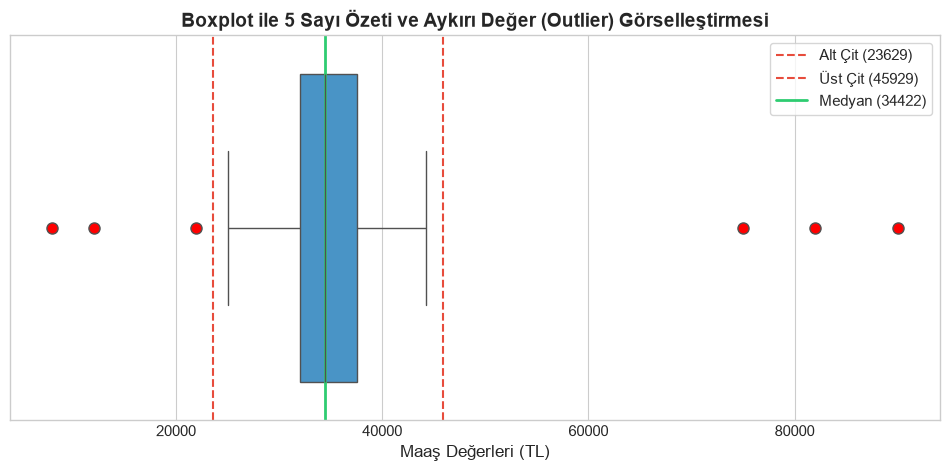

In [5]:
# Kutu Grafiği (Boxplot) ile Aykırı Değerlerin Görselleştirilmesi
plt.figure(figsize=(12, 5))

sns.boxplot(x=sample_data, color='#3498db', flierprops={'marker': 'o', 'markersize': 8, 'markerfacecolor': 'red'})
plt.axvline(lower_fence, color='#e74c3c', linestyle='--', label=f'Alt Çit ({lower_fence:.0f})')
plt.axvline(upper_fence, color='#e74c3c', linestyle='--', label=f'Üst Çit ({upper_fence:.0f})')
plt.axvline(median_val, color='#2ecc71', linestyle='-', linewidth=2, label=f'Medyan ({median_val:.0f})')

plt.title('Boxplot ile 5 Sayı Özeti ve Aykırı Değer (Outlier) Görselleştirmesi', fontsize=14, fontweight='bold')
plt.xlabel('Maaş Değerleri (TL)', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.show()

---
## 📈 Bölüm 4: Çarpıklık (Skewness) ve İlişki Ölçütleri

### 🔹 1. Çarpıklık Türleri ve Ortalama-Medyan-Mod İlişkisi

| Çarpıklık Türü | Şekil & Kuyruk | Değerler Sıralaması | Çarpıklık Katsayısı | Örnek |
| :--- | :--- | :--- | :--- | :--- |
| **Sağa Çarpık (Right / Positively Skewed)** | Sağ kuyruk uzun | $\text{Mod} < \text{Medyan} < \text{Ortalama}$ | $\text{Skew} > 0$ | Gelir dağılımı, ev fiyatları |
| **Simetrik (Symmetric / Normal)** | Çan eğrisi simetrik | $\text{Ortalama} \approx \text{Medyan} \approx \text{Mod}$ | $\text{Skew} \approx 0$ | Yetişkin boy uzunluğu |
| **Sola Çarpık (Left / Negatively Skewed)** | Sol kuyruk uzun | $\text{Ortalama} \le \text{Medyan} \le \text{Mod}$ | $\text{Skew} < 0$ | Emeklilik yaşı, kolay sınav notları |

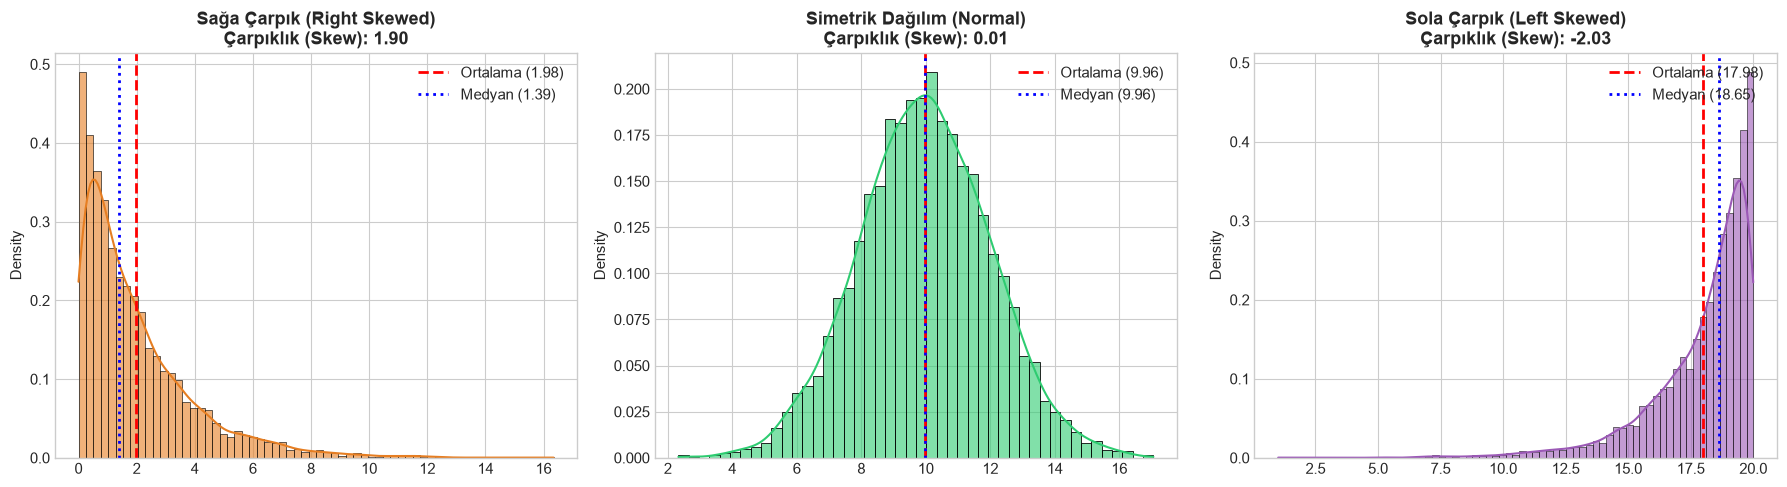

In [6]:
# 3 Farklı Dağılım Üretelim
np.random.seed(42)
n_pts = 5000

right_skewed = np.random.exponential(scale=2, size=n_pts)          # Sağa Çarpık
symmetric_data = np.random.normal(loc=10, scale=2, size=n_pts)     # Simetrik (Normal)
left_skewed = 20 - np.random.exponential(scale=2, size=n_pts)      # Sola Çarpık

datasets = [('Sağa Çarpık (Right Skewed)', right_skewed, '#e67e22'),
            ('Simetrik Dağılım (Normal)', symmetric_data, '#2ecc71'),
            ('Sola Çarpık (Left Skewed)', left_skewed, '#9b59b6')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (title, data, color) in enumerate(datasets):
    sns.histplot(data, kde=True, ax=axes[idx], color=color, stat="density", alpha=0.6)
    
    mean_d = np.mean(data)
    median_d = np.median(data)
    skew_d = stats.skew(data)
    
    axes[idx].axvline(mean_d, color='red', linestyle='--', linewidth=2, label=f'Ortalama ({mean_d:.2f})')
    axes[idx].axvline(median_d, color='blue', linestyle=':', linewidth=2, label=f'Medyan ({median_d:.2f})')
    axes[idx].set_title(f"{title}\nÇarpıklık (Skew): {skew_d:.2f}", fontsize=13, fontweight='bold')
    axes[idx].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 🔹 2. İki Değişken Arasındaki İlişki Ölçütleri: Kovaryans ve Korelasyon

- **Kovaryans (Covariance - $\text{Cov}(X, Y)$):** İki değişkenin birlikte nasıl değiştiğini gösterir (Yön belirtir, şiddet belirtmez):
  $$\text{Cov}(X, Y) = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$
  - $\text{Cov} > 0$: Biri artarken diğeri de artar.
  - $\text{Cov} < 0$: Biri artarken diğeri azalır.

- **Pearson Korelasyon Katsayısı ($r$):** Değişkenler arasındaki doğrusal ilişkinin hem yönünü hem de **şiddetini** $[-1, 1]$ aralığında standartlaştırarak ölçer:
  $$r = \frac{\text{Cov}(X, Y)}{s_X \cdot s_Y}, \quad -1 \le r \le 1$$

📊 Kovaryans Matrisi (.cov()):


,Calisma_Saati,Sinav_Notu,Sosyal_Medya_Saat
Calisma_Saati,5.63,37.19,-3.36
Sinav_Notu,37.19,272.38,-22.03
Sosyal_Medya_Saat,-3.36,-22.03,3.81



📊 Pearson Korelasyon Matrisi (.corr()):


,Calisma_Saati,Sinav_Notu,Sosyal_Medya_Saat
Calisma_Saati,1.00,0.95,-0.72
Sinav_Notu,0.95,1.00,-0.68
Sosyal_Medya_Saat,-0.72,-0.68,1.00


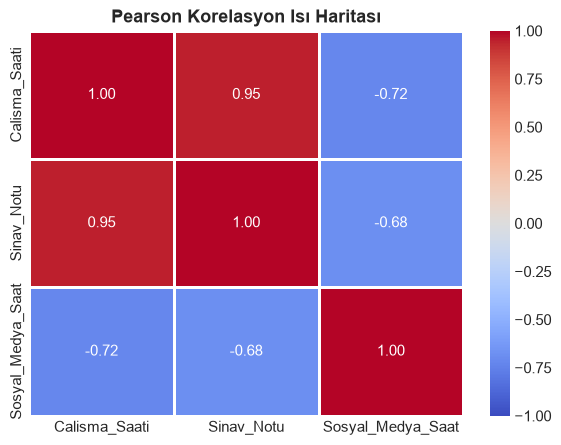

In [7]:
# Örnek İlişkili Değişkenler Oluşturalım
np.random.seed(42)
n_samples = 150

calisma_saati = np.random.uniform(2, 10, size=n_samples)                           # Çalışma Saati
sinav_notu = 35 + 6.5 * calisma_saati + np.random.normal(0, 5, size=n_samples)     # Not (Pozitif Korelasyon)
sosyal_medya = 8 - 0.6 * calisma_saati + np.random.normal(0, 1.5, size=n_samples) # Sosyal Medya (Negatif Korelasyon)

# pd.concat ile DataFrame birleştirme
df_features = pd.DataFrame({'Calisma_Saati': calisma_saati})
df_targets = pd.DataFrame({'Sinav_Notu': sinav_notu, 'Sosyal_Medya_Saat': sosyal_medya})
study_df = pd.concat([df_features, df_targets], axis=1)

# Kovaryans ve Korelasyon Matrisleri
cov_matrix = study_df.cov()
corr_matrix = study_df.corr(method='pearson')

print("📊 Kovaryans Matrisi (.cov()):")
display(cov_matrix.round(2))

print("\n📊 Pearson Korelasyon Matrisi (.corr()):")
display(corr_matrix.round(2))

# Isı Haritası (Heatmap) ile Görselleştirme
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('Pearson Korelasyon Isı Haritası', fontsize=13, fontweight='bold')
plt.show()

---
## 🎲 Bölüm 5: Olasılık Dağılım Fonksiyonları (PDF & PMF & CDF)

| Fonksiyon Türü | Açılımı | Değişken Türü | Anlamı / Formül |
| :--- | :--- | :--- | :--- |
| **PMF** | Probability Mass Function (Olasılık Kütle Fonksiyonu) | **Kesikli (Discrete)** | Noktasal olasılık: $P(X = k)$ |
| **PDF** | Probability Density Function (Olasılık Yoğunluk Fonksiyonu) | **Sürekli (Continuous)** | Alan olasılığı: $P(a \le X \le b) = \int_a^b f(x) dx$ |
| **CDF** | Cumulative Distribution Function (Kümülatif Dağılım Fonksiyonu) | **Her İkisi** | Birikimli olasılık: $F(x) = P(X \le x)$ |

### 🏠 Gerçek Hayat Örneği: Ev Fiyat Tahmini (House Price Prediction) Değişkenleri

- **Sürekli Değişkenler $\to$ PDF ile modellenir:**
  - `Fiyat (TL)`: Ölçülebilir reel para miktarı
  - `Metrekare / Boyut ($m^2$)`: Sürekli alan ölçümü
  - `Yeşil Alan Oranı (%)`: Yüzdelik sürekli oran
- **Kesikli & Kategorik Değişkenler $\to$ PMF ile modellenir:**
  - `Bulunduğu Kat`: Tam sayı (1, 2, 3...)
  - `Oda Sayısı`: Tam sayı (1, 2, 3, 4)
  - `Konum / İlçe Kodu`: Ayrık kategorik alan

<>:34: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:44: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:44: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:52: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:34: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:44: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:44: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences wil

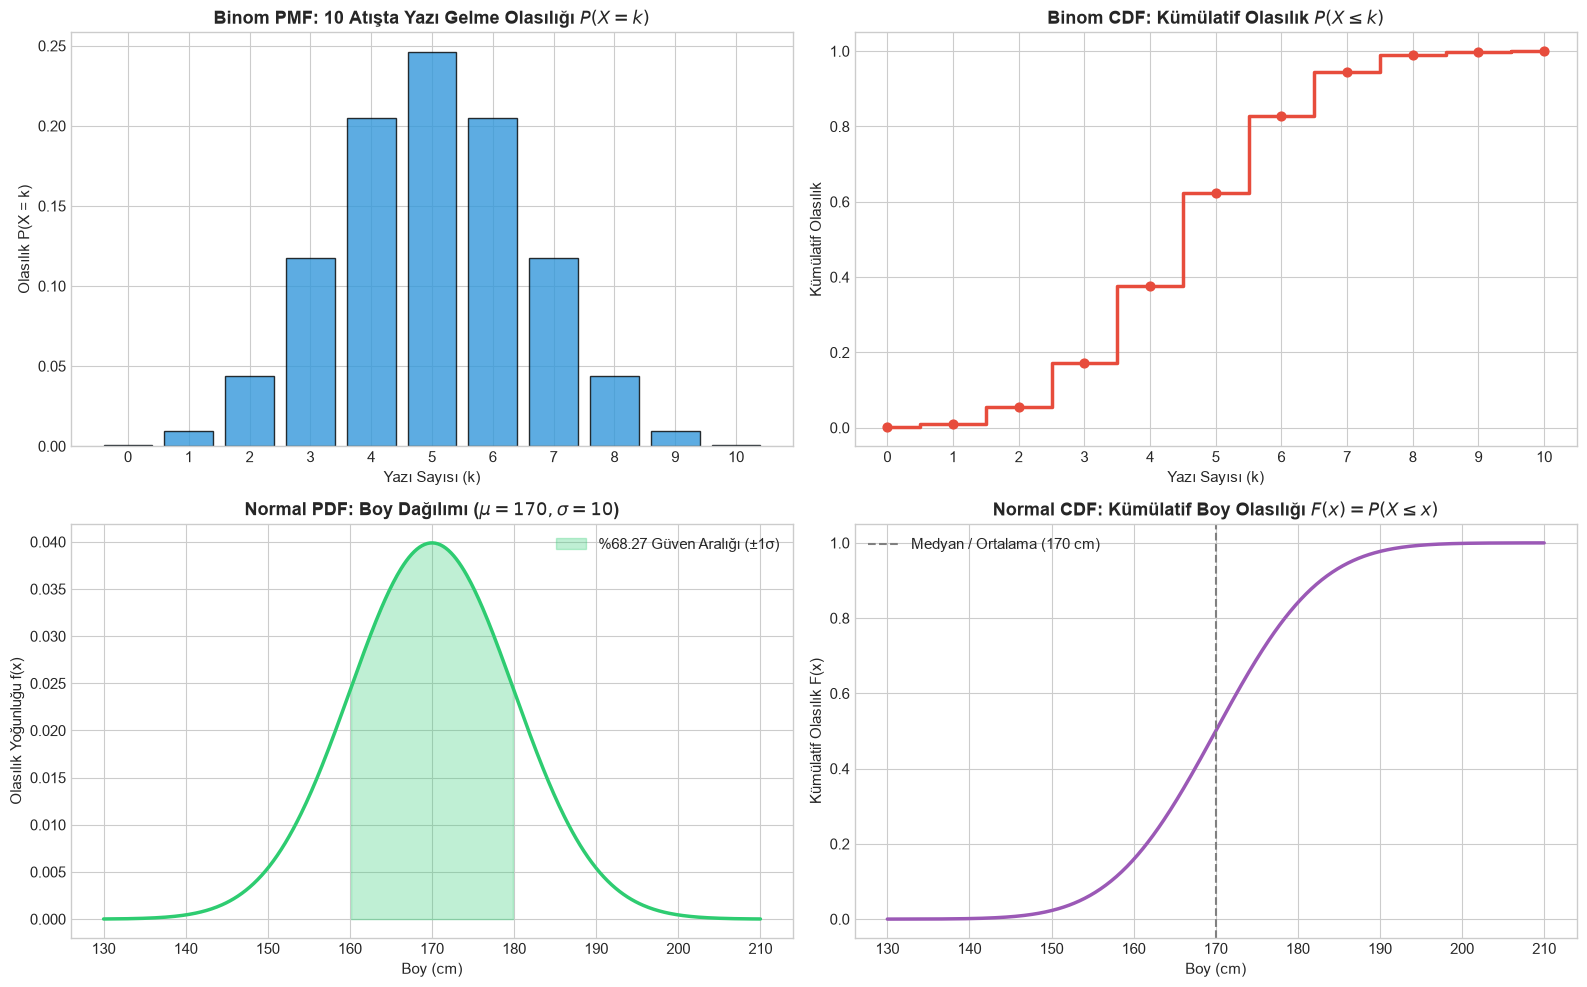

In [8]:
# ---------------------------------------------------------
# 1. Kesikli Dağılım Örneği: Binom Dağılımı (PMF & CDF)
# 10 kez madeni para atışı, p=0.5 başarı olasılığı
# ---------------------------------------------------------
n_flips = 10
p_head = 0.5
k_values = np.arange(0, n_flips + 1)

binom_pmf = stats.binom.pmf(k_values, n=n_flips, p=p_head)
binom_cdf = stats.binom.cdf(k_values, n=n_flips, p=p_head)

# ---------------------------------------------------------
# 2. Sürekli Dağılım Örneği: Normal Dağılım (PDF & CDF)
# Türkiye erkek boy ortalaması mu=170 cm, standart sapma sigma=10 cm
# ---------------------------------------------------------
mu_height, sigma_height = 170, 10
x_height = np.linspace(130, 210, 500)
norm_pdf = stats.norm.pdf(x_height, loc=mu_height, scale=sigma_height)
norm_cdf = stats.norm.cdf(x_height, loc=mu_height, scale=sigma_height)

# Grafik Çizimleri
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Binom PMF
axes[0, 0].bar(k_values, binom_pmf, color='#3498db', edgecolor='black', alpha=0.8)
axes[0, 0].set_title(f'Binom PMF: 10 Atışta Yazı Gelme Olasılığı $P(X = k)$', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Yazı Sayısı (k)')
axes[0, 0].set_ylabel('Olasılık P(X = k)')
axes[0, 0].set_xticks(k_values)

# 2. Binom CDF
axes[0, 1].step(k_values, binom_cdf, where='mid', color='#e74c3c', linewidth=2.5)
axes[0, 1].scatter(k_values, binom_cdf, color='#e74c3c', s=40)
axes[0, 1].set_title(f'Binom CDF: Kümülatif Olasılık $P(X \leq k)$', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Yazı Sayısı (k)')
axes[0, 1].set_ylabel('Kümülatif Olasılık')
axes[0, 1].set_xticks(k_values)

# 3. Normal PDF
axes[1, 0].plot(x_height, norm_pdf, color='#2ecc71', linewidth=2.5)
# 1 Standart sapma aralığını boyayalım (160 - 180 cm)
mask = (x_height >= 160) & (x_height <= 180)
axes[1, 0].fill_between(x_height[mask], norm_pdf[mask], color='#2ecc71', alpha=0.3, label='%68.27 Güven Aralığı (±1σ)')
axes[1, 0].set_title(f'Normal PDF: Boy Dağılımı ($\mu={mu_height}, \sigma={sigma_height}$)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Boy (cm)')
axes[1, 0].set_ylabel('Olasılık Yoğunluğu f(x)')
axes[1, 0].legend()

# 4. Normal CDF
axes[1, 1].plot(x_height, norm_cdf, color='#9b59b6', linewidth=2.5)
axes[1, 1].axvline(170, color='gray', linestyle='--', label='Medyan / Ortalama (170 cm)')
axes[1, 1].set_title(f'Normal CDF: Kümülatif Boy Olasılığı $F(x) = P(X \leq x)$', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Boy (cm)')
axes[1, 1].set_ylabel('Kümülatif Olasılık F(x)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---
## 🌐 Bölüm 6: Temel Olasılık Dağılımları Kataloğu

Veri biliminde en sık karşılaşılan 6 temel olasılık dağılımı:

1. **Bernoulli Dağılımı ($X \sim \text{Bernoulli}(p)$):**
   - Tek bir deneme ve 2 sonuç (Başarı $p$, Başarısızlık $1-p$).
   - $E[X] = p$, $\text{Var}(X) = p(1-p)$.
2. **Binom Dağılımı ($X \sim \text{Binomial}(n, p)$):**
   - Bağımsız $n$ adet Bernoulli denemesindeki başarı sayısı.
   - $E[X] = np$, $\text{Var}(X) = np(1-p)$.
3. **Normal / Gauss Dağılımı ($X \sim \mathcal{N}(\mu, \sigma^2)$):**
   - Doğadaki çoğu sürekli değişkeni modelleyen simetrik çan eğrisi (Merkezi Limit Teoremi).
   - Empirik Kural: $\mu \pm 1\sigma \to %68.3$, $\mu \pm 2\sigma \to %95.4$, $\mu \pm 3\sigma \to %99.7$.
4. **Log-Normal Dağılım:**
   - Logaritması alındığında Normal dağılıma dönüşen pozitif çarpık sürekli dağılım (Gelirler, borsa fiyatları, internet trafiği).
5. **Pareto Dağılımı (80/20 Kuralı):**
   - Güç yasası (Power law) dağılımı. Zenginliğin %80'inin nüfusun %20'sinde toplanması gibi aşırı dengesiz durumları modeller.
6. **Düzgün Dağılım (Uniform Distribution - Ayrık/Sürekli):**
   - Belirli bir aralıktaki tüm değerlerin eşit olasılığa sahip olduğu durum (Örn: Hilesiz zar atışı, rastgele sayı üreteçleri).

---
## 📝 Bölüm 7: Özet ve Hızlı Başvuru Kartı

| Kavram | Tür | Formül / Kural | Python Kütüphanesi |
| :--- | :--- | :--- | :--- |
| **Ortalama** | Merkezi Eğilim | $\bar{x} = \frac{\sum x_i}{n}$ | `np.mean()`, `df.mean()` |
| **Medyan** | Merkezi Eğilim | $Q_2$ (Ortadaki değer) | `np.median()`, `df.median()` |
| **Standart Sapma** | Yayılım | $s = \sqrt{\frac{\sum(x_i - \bar{x})^2}{n-1}}$ | `np.std(ddof=1)`, `df.std()` |
| **IQR** | Yayılım | $Q_3 - Q_1$ | `scipy.stats.iqr()` |
| **Aykırı Değerler** | Aykırı Analizi | $x < Q_1 - 1.5\text{IQR}$ veya $x > Q_3 + 1.5\text{IQR}$ | NumPy boolean maskeleme |
| **Sağa Çarpık** | Şekil | $\text{Mod} < \text{Medyan} < \text{Ortalama}$ | `scipy.stats.skew() > 0` |
| **Sola Çarpık** | Şekil | $\text{Ortalama} \le \text{Medyan} \le \text{Mod}$ | `scipy.stats.skew() < 0` |
| **Kovaryans** | İlişki | $\text{Cov}(X, Y)$ | `df.cov()` |
| **Korelasyon** | İlişki | $r = \frac{\text{Cov}(X, Y)}{s_X s_Y} \in [-1, 1]$ | `df.corr(method='pearson')` |
| **PMF** | Olasılık | Kesikli $P(X = k)$ | `scipy.stats.<dist>.pmf()` |
| **PDF** | Olasılık | Sürekli $f(x)$ | `scipy.stats.<dist>.pdf()` |
| **CDF** | Olasılık | Birikimli $P(X \le x)$ | `scipy.stats.<dist>.cdf()` |

---